# Other offline learning algorithms

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym


import d3rlpy
from d3rlpy.datasets import get_cartpole
from d3rlpy.algos import DQNConfig, TD3Config
from d3rlpy.metrics import TDErrorEvaluator, EnvironmentEvaluator

from pmind.replay import convert_rb_to_dataset

from pmind.config.loader import load_config
from omegaconf import OmegaConf

import bbrl_gymnasium

from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [123]:
ENV_NAME = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    # "LunarLanderContinuous-v3",
)[1]
MODELS_DIR = f"../models/{ENV_NAME}/"
env = gym.make(ENV_NAME)


cfg = load_config("td3")
cfg = OmegaConf.create(cfg.environments[ENV_NAME])

In [124]:
MAX_STEPS = 50_000 #100_000
NB_EVAL_ENVS = 3 #10 # TODO: use it?
EVAL_INTERVAL = 1000 #100
SAVE_RB_POLICY_INTERVAL = 2_000 # TODO: use it
BATCH_SIZE = 64 #64
NN_ARCHITECTURE = [32,16] #[400,300] [32,16]
LR = 1e-3

cfg_offline = OmegaConf.create(cfg)
cfg_offline.algorithm.n_steps = MAX_STEPS
cfg_offline.algorithm.max_epochs = None

cfg_offline.actor_optimizer.lr = LR
cfg_offline.critic_optimizer.lr = LR

cfg_offline.algorithm.batch_size = BATCH_SIZE
cfg_offline.algorithm.architecture.actor_hidden_size = NN_ARCHITECTURE
cfg_offline.algorithm.architecture.critic_hidden_size = NN_ARCHITECTURE


cfg_offline.algorithm.eval_interval = EVAL_INTERVAL
cfg_offline.algorithm.nb_evals = NB_EVAL_ENVS  # nb of evaluation envs in parallel
    
cfg_offline.algorithm.save_rb_policy_interval = SAVE_RB_POLICY_INTERVAL

# learning starts immediately for offline:
cfg_offline.algorithm.learning_starts = None

# there is no exploration in offline learning
cfg_offline.algorithm.action_noise = None
# cfg_offline.algorithm.target_policy_noise = None # #TODO: correct?

we will try those algos:

```py
d3rlpy.algos.BCConfig()
d3rlpy.algos.TD3PlusBCConfig()
d3rlpy.algos.TD3Config()
d3rlpy.algos.IQLConfig()
```

Note that BC ignores the reward.

NOTE: what they call an "epoch" here is not about a pass
through the whole dataset, but just a logging checkpoint

In [125]:
# TODO: adapt config from TD3: nn architecture, action_scale, algo config...
rb_name = "rb--84"
rb = torch.load(MODELS_DIR + f"{rb_name}.pt", weights_only=False)

dataset = convert_rb_to_dataset(rb, contains_teleportation="unif" in rb_name)

action_scaler = d3rlpy.preprocessing.MinMaxActionScaler(
    minimum=np.array(-1.0 * cfg_offline.action_scaling),
    maximum=np.array(1.0 * cfg_offline.action_scaling),
)
critic_encoder_factory = d3rlpy.models.VectorEncoderFactory(
    hidden_units=cfg_offline.algorithm.architecture.critic_hidden_size,
    activation="tanh",
)

actor_encoder_factory = d3rlpy.models.VectorEncoderFactory(
    hidden_units=cfg_offline.algorithm.architecture.actor_hidden_size,
    activation="tanh",
)

# Setup algorithm
algo = d3rlpy.algos.IQLConfig(
    gamma=cfg_offline.algorithm.discount_factor,
    actor_learning_rate=cfg_offline.actor_optimizer.lr,
    critic_learning_rate=cfg_offline.critic_optimizer.lr,
    batch_size=cfg_offline.algorithm.batch_size,
    tau=cfg_offline.algorithm.tau_target,
    action_scaler=action_scaler,
    actor_encoder_factory=critic_encoder_factory,
    critic_encoder_factory=actor_encoder_factory,
    # target_smoothing_clip=cfg_offline.algorithm.target_policy_noise_clip,
    # target_smoothing_sigma=cfg_offline.algorithm.target_policy_noise #TODO: correct?
).create(device=None)

# Initialize NN with right obs and action dims
algo.build_with_dataset(dataset)

# Setup metrics

# This metric suggests how Q functions overfit to training sets.
# If the TD error is large, the Q functions are overfitting.
# td_error_evaluator = TDErrorEvaluator(episodes=dataset.episodes)

env_evaluator = EnvironmentEvaluator(env, n_trials=10)

rewards = env_evaluator(algo, dataset=None)
print(f"Reward at initialization: {rewards}")

2026-04-29 17:58.53 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-04-29 17:58.53 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-04-29 17:58.53 [info     ] Action size has been automatically determined. action_size=1
Reward at initialization: -1341.6975990175065


In [128]:
pbar = tqdm(total= int(cfg_offline.algorithm.n_steps / cfg_offline.algorithm.eval_interval) )

# Offline training
offline_log = algo.fit(
    dataset,
    n_steps=cfg_offline.algorithm.n_steps,
    n_steps_per_epoch=cfg_offline.algorithm.eval_interval,
    evaluators={
        # 'td_error': td_error_evaluator,
        "environment": env_evaluator
    },
    show_progress=False,
    epoch_callback=lambda algo, epoch, total_step: pbar.update(1)
)

pbar.close()

  0%|          | 0/50 [00:00<?, ?it/s]

2026-04-29 18:00.00 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(3,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-04-29 18:00.00 [warning  ] Skip building models since they're already built.
2026-04-29 18:00.00 [info     ] Directory is created at d3rlpy_logs/IQL_20260429180000
2026-04-29 18:00.00 [info     ] Parameters                     params={'observation_shape': [3], 'action_size': 1, 'config': {'type': 'iql', 'params': {'batch_size': 64, 'gamma': 0.99, 'observation_scaler': {'type': 'none', 'params': {}}, 'action_scaler': {'type': 'min_max', 'params': {'minimum': -2.0, 'maximum': 2.0}}, 'reward_scaler': {'type': 'none', 'params': {}}, 'compile_graph': False, 'actor_learning_rate': 0.001, 'critic_learning_rate': 0.001, 'actor_optim_factory'

KeyboardInterrupt: 

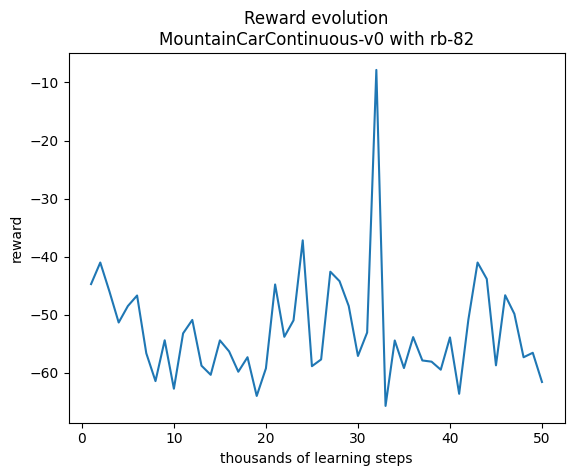

In [121]:
epochs, logs = zip(*offline_log)
df_logs = pd.DataFrame(logs, index=epochs)
plt.plot(df_logs.index, df_logs.environment)
plt.title(f"Reward evolution\n{ENV_NAME} with {rb_name}")
plt.ylabel("reward")
plt.xlabel("thousands of learning steps")
plt.show()

In [ ]:
action = algo.predict(env.observation_space.sample().reshape(1,-1))
action

array([[0.76689553]], dtype=float32)

In [90]:
#TODO: understand how to get the best policy...